# Analyse du dataset RPG IGN 2024 — Hauts-de-France

## Source
**Registre Parcellaire Graphique (RPG)** — IGN / Agence de Services et de Paiement (ASP)  
Téléchargé sur : **geoservices.ign.fr/rpg**  
Format brut : **GeoPackage (.gpkg)** — format géographique standard OGC  
Licence : Etalab (open data gratuit)

## Pourquoi un fichier .gpkg ?
Le RPG est un fichier **géographique** : chaque parcelle a non seulement des attributs (culture, surface) mais aussi une **géométrie** — le polygone exact de la parcelle sur la carte. Le format GeoPackage (.gpkg) est une base de données SQLite qui stocke à la fois les attributs et les géométries dans un seul fichier.

## Structure de ce notebook
1. Lecture du fichier brut `.gpkg` et exploration de sa structure
2. Compréhension de chaque colonne (dont la géométrie)
3. Conversion en CSV léger (sans géométrie)
4. Analyse statistique du dataset
5. Visualisations

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 1 — Installation et imports                     ║
# ║                                                          ║
# ║  geopandas : librairie pour lire les fichiers            ║
# ║  géographiques (.gpkg, .shp, .geojson...)                ║
# ║  fiona     : moteur de lecture des formats géo           ║
# ╚══════════════════════════════════════════════════════════╝

!pip install geopandas fiona matplotlib -q

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#fafafa'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

COULEURS = {
    'ble_tendre':'#f59e0b', 'mais_grain':'#f97316', 'orge':'#84cc16',
    'betterave':'#8b5cf6', 'pomme_de_terre':'#d97706', 'colza':'#eab308',
    'lin_fibre':'#3b82f6', 'pois_proteine':'#22c55e',
}
NOMS = {
    'ble_tendre':'Blé tendre', 'mais_grain':'Maïs grain', 'orge':'Orge',
    'betterave':'Betterave', 'pomme_de_terre':'Pomme de terre',
    'colza':'Colza', 'lin_fibre':'Lin fibre', 'pois_proteine':'Pois protéagineux',
}
CULTURES_MODELE = list(COULEURS.keys())
print('✓ Imports OK')

✓ Imports OK


In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Upload du fichier brut .gpkg                ║
# ╚══════════════════════════════════════════════════════════╝

from google.colab import files
print('Uploader le fichier RPG_Parcelles.gpkg (fichier brut IGN)')
print('Attention : ce fichier peut peser plusieurs centaines de Mo')
uploaded = files.upload()
GPG_FILE = list(uploaded.keys())[0]
print(f'✓ Fichier reçu : {GPG_FILE}')

Uploader le fichier RPG_Parcelles.gpkg (fichier brut IGN)
Attention : ce fichier peut peser plusieurs centaines de Mo


Saving RPG_Parcelles.gpkg to RPG_Parcelles.gpkg
✓ Fichier reçu : RPG_Parcelles.gpkg


In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Lecture du fichier brut et structure        ║
# ║                                                          ║
# ║  On lit le .gpkg avec geopandas qui retourne un          ║
# ║  GeoDataFrame — comme un DataFrame pandas mais avec      ║
# ║  une colonne 'geometry' supplémentaire contenant         ║
# ║  le polygone géographique de chaque parcelle.            ║
# ╚══════════════════════════════════════════════════════════╝

print('Lecture du fichier brut (peut prendre 1-2 minutes)...')
gdf = gpd.read_file(GPG_FILE)

print(f'\n✓ Fichier lu : {len(gdf):,} parcelles')
print(f'   Type      : {type(gdf).__name__} (GeoDataFrame geopandas)')
print()

print('=== TOUTES LES COLONNES DU FICHIER BRUT ===')
print()
for col in gdf.columns:
    dtype = gdf[col].dtype
    n_null = gdf[col].isna().sum()
    exemple = gdf[col].dropna().iloc[0] if gdf[col].notna().any() else 'N/A'
    # Tronquer les exemples longs (geometry)
    exemple_str = str(exemple)[:60] + '...' if len(str(exemple)) > 60 else str(exemple)
    print(f'  {col:<20} type={str(dtype):<15} null={n_null:>6,}  ex: {exemple_str}')

Lecture du fichier brut (peut prendre 1-2 minutes)...

✓ Fichier lu : 566,044 parcelles
   Type      : GeoDataFrame (GeoDataFrame geopandas)

=== TOUTES LES COLONNES DU FICHIER BRUT ===

  id_parcel            type=object          null=     0  ex: 2247482
  surf_parc            type=float64         null=     0  ex: 0.0
  code_cultu           type=object          null=     0  ex: AAR
  code_group           type=object          null=     0  ex: 24
  culture_d1           type=object          null=539,501  ex: DMD
  culture_d2           type=object          null=539,534  ex: DRD
  cat_cult_p           type=object          null=27,314  ex: TA
  geometry             type=geometry        null=     0  ex: MULTIPOLYGON (((689565.5891999975 7038678.768599998, 689567....


In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Explication détaillée de chaque colonne     ║
# ║                                                          ║
# ║  Pourquoi ces colonnes existent, d'où elles viennent,    ║
# ║  et ce qu'on en fait dans notre projet.                  ║
# ╚══════════════════════════════════════════════════════════╝

print('=== EXPLICATION DE CHAQUE COLONNE ===')
print()

EXPLICATIONS = {
    'geometry': (
        'GÉOMÉTRIE — Le polygone exact de la parcelle (frontières GPS).\n'
        '   Origine  : tracé par photo-interprétation ou GPS par l\'IGN.\n'
        '   Format   : MULTIPOLYGON en Lambert 93 (projection française officielle).\n'
        '   Exemple  : MULTIPOLYGON (((702345.2 6821453.1, 702389.4 ...)))\n'
        '   Utilisation dans notre projet : on extrait le centroïde (centre\n'
        '   géographique) pour faire la jointure spatiale avec le SGDBE INRAE.\n'
        '   On supprime ensuite la geometry pour alléger le fichier.'
    ),
    'id_parcel': (
        'IDENTIFIANT UNIQUE — Code alphanumérique unique par parcelle.\n'
        '   Origine  : généré par Telepac lors de la déclaration PAC.\n'
        '   Format   : chaîne de caractères (ex: 062-00012345-001)\n'
        '   Utilisation : clé de jointure entre RPG 2024 et RPG 2023\n'
        '   pour récupérer le précédent cultural de l\'année précédente.'
    ),
    'code_cultu': (
        'CODE CULTURE — Code officiel de la culture déclarée (3 lettres).\n'
        '   Origine  : déclaration annuelle de l\'agriculteur sur Telepac.\n'
        '   Format   : code normalisé IGN (ex: BTH = Blé Tendre Hiver)\n'
        '   Exemples : BTH, MIS, ORH, CZH, BTN, PTC, LIF, PPR...\n'
        '   Utilisation : variable cible du modèle après mapping\n'
        '   vers nos 8 cultures (BTH → ble_tendre, MIS → mais_grain...)'
    ),
    'surf_parc': (
        'SURFACE — Surface de la parcelle en hectares.\n'
        '   Origine  : calculée automatiquement depuis la géométrie par l\'IGN.\n'
        '   Format   : float (ex: 4.823)\n'
        '   Utilisation : feature numérique du modèle + filtre >= 0.5 ha'
    ),
    'code_dep': (
        'DÉPARTEMENT — Code du département (02, 59, 60, 62, 80).\n'
        '   Origine  : déduit de la position géographique de la parcelle.\n'
        '   Utilisation : permet de filtrer sur les HdF uniquement.'
    ),
    'nom_dep': (
        'NOM DÉPARTEMENT — Libellé du département.\n'
        '   Exemples : Aisne, Nord, Oise, Pas-de-Calais, Somme'
    ),
    'code_commune': (
        'CODE COMMUNE INSEE — Code officiel de la commune.\n'
        '   Utilisation potentielle : jointure avec données BDAT INRAE\n'
        '   pour les analyses de sol à l\'échelle communale.'
    ),
}

for col in gdf.columns:
    expl = EXPLICATIONS.get(col, f'Colonne présente dans le RPG — non utilisée dans notre modèle.')
    print(f'📌 {col.upper()}')
    for line in expl.split('\n'):
        print(f'   {line}')
    print()

=== EXPLICATION DE CHAQUE COLONNE ===

📌 ID_PARCEL
   IDENTIFIANT UNIQUE — Code alphanumérique unique par parcelle.
      Origine  : généré par Telepac lors de la déclaration PAC.
      Format   : chaîne de caractères (ex: 062-00012345-001)
      Utilisation : clé de jointure entre RPG 2024 et RPG 2023
      pour récupérer le précédent cultural de l'année précédente.

📌 SURF_PARC
   SURFACE — Surface de la parcelle en hectares.
      Origine  : calculée automatiquement depuis la géométrie par l'IGN.
      Format   : float (ex: 4.823)
      Utilisation : feature numérique du modèle + filtre >= 0.5 ha

📌 CODE_CULTU
   CODE CULTURE — Code officiel de la culture déclarée (3 lettres).
      Origine  : déclaration annuelle de l'agriculteur sur Telepac.
      Format   : code normalisé IGN (ex: BTH = Blé Tendre Hiver)
      Exemples : BTH, MIS, ORH, CZH, BTN, PTC, LIF, PPR...
      Utilisation : variable cible du modèle après mapping
      vers nos 8 cultures (BTH → ble_tendre, MIS → mais_grai

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 5 — Zoom sur la colonne geometry                ║
# ║                                                          ║
# ║  La geometry est la colonne la plus volumineuse et       ║
# ║  la moins intuitive. On l'explore en détail.             ║
# ╚══════════════════════════════════════════════════════════╝

print('=== ZOOM SUR LA COLONNE GEOMETRY ===')
print()

# Projection
print(f'Système de projection : {gdf.crs}')
print('→ Lambert 93 (EPSG:2154) : projection officielle française')
print('  Les coordonnées sont en MÈTRES (pas en degrés lat/lon)')
print()

# Emprise géographique
bounds = gdf.total_bounds
print(f'Emprise géographique (Lambert 93) :')
print(f'  X min : {bounds[0]:,.0f} m    X max : {bounds[2]:,.0f} m')
print(f'  Y min : {bounds[1]:,.0f} m    Y max : {bounds[3]:,.0f} m')
print()

# Exemple de geometry
print('Exemple de geometry pour la 1ère parcelle :')
geom = gdf.geometry.iloc[0]
print(f'  Type    : {geom.geom_type}')
print(f'  Aire    : {geom.area:.0f} m² = {geom.area/10000:.2f} ha')
print(f'  Centroïde (Lambert 93) : ({geom.centroid.x:.1f}, {geom.centroid.y:.1f})')
print()

# Types de géométrie
print('Types de géométrie présents :')
print(gdf.geom_type.value_counts().to_string())
print()
print('Note : MULTIPOLYGON = parcelle avec plusieurs îlots séparés')
print('       POLYGON = parcelle d\'un seul tenant (cas le plus fréquent)')

# Taille mémoire
import sys
size_mb = gdf.memory_usage(deep=True).sum() / 1024**2
size_no_geom = gdf.drop(columns='geometry').memory_usage(deep=True).sum() / 1024**2
print()
print(f'Taille mémoire avec geometry    : {size_mb:.0f} Mo')
print(f'Taille mémoire sans geometry    : {size_no_geom:.0f} Mo')
print(f'La geometry représente          : {(size_mb-size_no_geom)/size_mb*100:.0f}% de la mémoire')

=== ZOOM SUR LA COLONNE GEOMETRY ===

Système de projection : EPSG:2154
→ Lambert 93 (EPSG:2154) : projection officielle française
  Les coordonnées sont en MÈTRES (pas en degrés lat/lon)

Emprise géographique (Lambert 93) :
  X min : 584,793 m    X max : 790,651 m
  Y min : 6,859,800 m    Y max : 7,108,927 m

Exemple de geometry pour la 1ère parcelle :
  Type    : MultiPolygon
  Aire    : 41 m² = 0.00 ha
  Centroïde (Lambert 93) : (689569.9, 7038667.9)

Types de géométrie présents :
MultiPolygon    566044

Note : MULTIPOLYGON = parcelle avec plusieurs îlots séparés
       POLYGON = parcelle d'un seul tenant (cas le plus fréquent)

Taille mémoire avec geometry    : 148 Mo
Taille mémoire sans geometry    : 144 Mo
La geometry représente          : 3% de la mémoire


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 6 — Extraction des coordonnées GPS              ║
# ║                                                          ║
# ║  On extrait le centroïde (centre) de chaque parcelle     ║
# ║  en WGS84 (lat/lon standard) pour la jointure sol.       ║
# ║  C'est la seule information géographique qu'on garde.    ║
# ╚══════════════════════════════════════════════════════════╝

print('Extraction des centroïdes en WGS84 (lat/lon)...')

# Calculer le centroïde de chaque polygone (en Lambert 93)
gdf['centroid_l93'] = gdf.geometry.centroid

# Convertir en WGS84 (EPSG:4326) pour avoir des lat/lon
centroids_wgs84 = gdf['centroid_l93'].to_crs('EPSG:4326')
gdf['lon'] = centroids_wgs84.x
gdf['lat'] = centroids_wgs84.y

print(f'✓ Coordonnées extraites pour {len(gdf):,} parcelles')
print()
print('Exemples de centroïdes (WGS84) :')
print(gdf[['id_parcel','code_cultu','surf_parc','lat','lon']].head(5).to_string())
print()
print(f'Emprise HdF en WGS84 :')
print(f'  Latitude  : {gdf.lat.min():.3f}° N — {gdf.lat.max():.3f}° N')
print(f'  Longitude : {gdf.lon.min():.3f}° E — {gdf.lon.max():.3f}° E')
print()
print('Ces coordonnées serviront à :')
print('  1. Jointure avec SGDBE INRAE (type de sol réel)')
print('  2. Jointure avec Open-Meteo (météo réelle 2023)')
print('  → Sauvegardées dans rpg_coords.csv')

# Sauvegarder les coordonnées
gdf[['id_parcel','lat','lon']].to_csv('rpg_coords.csv', index=False)
print('✓ rpg_coords.csv sauvegardé')

Extraction des centroïdes en WGS84 (lat/lon)...
✓ Coordonnées extraites pour 566,044 parcelles

Exemples de centroïdes (WGS84) :
  id_parcel code_cultu  surf_parc        lat       lon
0   2247482        AAR        0.0  50.445409  2.853374
1  11103818        BFS        0.0  49.706889  1.716973
2   7775272        BFS        0.0  49.847463  1.815488
3  11158312        BFS        0.0  50.821740  1.818159
4  11438981        BFS        0.0  50.027526  1.881612

Emprise HdF en WGS84 :
  Latitude  : 48.838° N — 51.073° N
  Longitude : 1.394° E — 4.256° E

Ces coordonnées serviront à :
  1. Jointure avec SGDBE INRAE (type de sol réel)
  2. Jointure avec Open-Meteo (météo réelle 2023)
  → Sauvegardées dans rpg_coords.csv
✓ rpg_coords.csv sauvegardé


In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 7 — Conversion en CSV léger                     ║
# ║                                                          ║
# ║  On supprime la geometry pour créer un fichier CSV       ║
# ║  léger utilisable directement dans pandas.               ║
# ╚══════════════════════════════════════════════════════════╝

print('=== CONVERSION .gpkg → .csv ===')
print()
print('Colonnes conservées (sans geometry) :')
cols_utiles = [c for c in gdf.columns if c not in ['geometry','centroid_l93']]
for c in cols_utiles:
    print(f'  ✓ {c}')
print()
print('Colonnes supprimées :')
print('  ✗ geometry     → polygone géographique (non nécessaire pour le ML)')
print('  ✗ centroid_l93 → coordonnées Lambert 93 intermédiaires')
print()

df_light = gdf[cols_utiles].copy()
df_light.to_csv('rpg_parcelles_light.csv', index=False)

import os
size_gpkg = os.path.getsize(GPG_FILE) / 1024**2
size_csv  = os.path.getsize('rpg_parcelles_light.csv') / 1024**2

print(f'Taille .gpkg  : {size_gpkg:.0f} Mo')
print(f'Taille .csv   : {size_csv:.0f} Mo')
print(f'Réduction     : {(1-size_csv/size_gpkg)*100:.0f}%')
print()
print(f'✓ {len(df_light):,} parcelles → rpg_parcelles_light.csv')

=== CONVERSION .gpkg → .csv ===

Colonnes conservées (sans geometry) :
  ✓ id_parcel
  ✓ surf_parc
  ✓ code_cultu
  ✓ code_group
  ✓ culture_d1
  ✓ culture_d2
  ✓ cat_cult_p
  ✓ lon
  ✓ lat

Colonnes supprimées :
  ✗ geometry     → polygone géographique (non nécessaire pour le ML)
  ✗ centroid_l93 → coordonnées Lambert 93 intermédiaires

Taille .gpkg  : 314 Mo
Taille .csv   : 33 Mo
Réduction     : 89%

✓ 566,044 parcelles → rpg_parcelles_light.csv


In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 8 — Mapping codes → cultures modèle             ║
# ║                                                          ║
# ║  Le RPG contient des dizaines de codes cultures.         ║
# ║  On les regroupe en 8 catégories pour notre modèle.      ║
# ╚══════════════════════════════════════════════════════════╝

CODE_CULTURES = {
    'BTH':'ble_tendre','BTP':'ble_tendre','BTA':'ble_tendre',
    'BDH':'ble_dur','BDP':'ble_dur',
    'ORH':'orge','ORP':'orge',
    'MIS':'mais_grain','MDE':'mais_grain','MID':'mais_grain',
    'CZH':'colza','CZP':'colza',
    'LIF':'lin_fibre','LIN':'lin_fibre','LBF':'lin_fibre','CHV':'lin_fibre',
    'PPR':'pois_proteine',
    'BTN':'betterave','PTC':'pomme_de_terre','PTR':'pomme_de_terre',
    'PPH':'prairie','LUZ':'prairie','PHF':'prairie','PHI':'prairie',
    'JAC':'jachere','JNO':'jachere',
    'TRN':'triticale','TRH':'triticale',
    'AVP':'autres_cereales','AVH':'autres_cereales','SGH':'autres_cereales',
}

df_light['culture'] = df_light['code_cultu'].map(CODE_CULTURES)

n_total   = len(df_light)
n_mapped  = df_light['culture'].notna().sum()
n_modele  = df_light['culture'].isin(CULTURES_MODELE).sum()
n_non_mapped = df_light['culture'].isna().sum()

print('=== RÉSULTAT DU MAPPING ===')
print(f'  Parcelles totales                  : {n_total:>10,}')
print(f'  Codes reconnus (mappés)            : {n_mapped:>10,}  ({n_mapped/n_total*100:.1f}%)')
print(f'  Dans les 8 cultures modèle         : {n_modele:>10,}  ({n_modele/n_total*100:.1f}%)')
print(f'  Non mappés (prairies, jachères...) : {n_non_mapped:>10,}  ({n_non_mapped/n_total*100:.1f}%)')
print()

# Codes non mappés les plus fréquents
non_mappes = df_light[df_light['culture'].isna()]['code_cultu'].value_counts().head(15)
print('Top 15 codes non retenus dans le modèle :')
print(f'{"Code":<10} {"N parcelles":>12}  Raison')
print('-'*55)
RAISONS = {
    'PPH':'Prairie permanente — hors périmètre',
    'JAC':'Jachère — hors périmètre',
    'LUZ':'Luzerne — hors périmètre',
    'TRN':'Triticale — céréale secondaire',
    'BDH':'Blé dur — différent du blé tendre',
    'FVP':'Féveroles — légumineuse secondaire',
    'SGH':'Sorgho — hors périmètre HdF',
    'AVH':'Avoine hiver — céréale secondaire',
}
for code, n in non_mappes.items():
    raison = RAISONS.get(code, 'Non retenu dans les 8 cultures cibles')
    print(f'  {code:<8} {n:>12,}  {raison}')

=== RÉSULTAT DU MAPPING ===
  Parcelles totales                  :    566,044
  Codes reconnus (mappés)            :    498,987  (88.2%)
  Dans les 8 cultures modèle         :    334,839  (59.2%)
  Non mappés (prairies, jachères...) :     67,057  (11.8%)

Top 15 codes non retenus dans le modèle :
Code        N parcelles  Raison
-------------------------------------------------------
  SNE            36,702  Non retenu dans les 8 cultures cibles
  BOR             5,873  Non retenu dans les 8 cultures cibles
  MLG             2,179  Non retenu dans les 8 cultures cibles
  BFS             2,013  Non retenu dans les 8 cultures cibles
  TRE             1,562  Non retenu dans les 8 cultures cibles
  FVP             1,319  Féveroles — légumineuse secondaire
  MSW             1,308  Non retenu dans les 8 cultures cibles
  MDI             1,281  Non retenu dans les 8 cultures cibles
  FLA             1,023  Non retenu dans les 8 cultures cibles
  VRC             1,012  Non retenu dans les 8 cul

In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 9 — Filtrage final                              ║
# ║                                                          ║
# ║  Application des 2 filtres successifs :                  ║
# ║  1. Garder uniquement les 8 cultures modèle              ║
# ║  2. Supprimer les parcelles < 0.5 ha                     ║
# ╚══════════════════════════════════════════════════════════╝

# Filtre 1
df = df_light[df_light['culture'].isin(CULTURES_MODELE)].copy()
n_f1 = len(df)

# Filtre 2
df = df[df['surf_parc'] >= 0.5].copy()
n_f2 = len(df)

print('=== FILTRAGE ===')
print(f'  Brut                           : {n_total:>10,}')
print(f'  Après filtre cultures modèle   : {n_f1:>10,}  (-{n_total-n_f1:,})')
print(f'  Après filtre surface >= 0.5 ha : {n_f2:>10,}  (-{n_f1-n_f2:,})')
print()
print(f'  ✓ DATASET FINAL : {n_f2:,} parcelles')

=== FILTRAGE ===
  Brut                           :    566,044
  Après filtre cultures modèle   :    334,839  (-231,205)
  Après filtre surface >= 0.5 ha :    294,808  (-40,031)

  ✓ DATASET FINAL : 294,808 parcelles


In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 10 — Distribution des cultures                  ║
# ╚══════════════════════════════════════════════════════════╝

dist = df['culture'].value_counts()

PARTS_AGRESTE = {
    'ble_tendre':35,'mais_grain':18,'orge':10,'betterave':12,
    'pomme_de_terre':8,'colza':7,'lin_fibre':6,'pois_proteine':4
}

print('=== DISTRIBUTION DES CULTURES ===')
print(f'{"Culture":<22} {"N parcelles":>12} {"% dataset":>10} {"% SAU Agreste 2023":>20} {"Écart":>8}')
print('-' * 78)
for c in CULTURES_MODELE:
    n   = dist.get(c, 0)
    pct = n / len(df) * 100
    agr = PARTS_AGRESTE.get(c, 0)
    print(f'  {NOMS[c]:<20} {n:>12,} {pct:>9.1f}% {agr:>19}%  {pct-agr:>+7.1f}%')
print()
print(f'Déséquilibre : {dist.max():,} (blé) vs {dist.min():,} (pois) = ratio {dist.max()//dist.min()}:1')

=== DISTRIBUTION DES CULTURES ===
Culture                 N parcelles  % dataset   % SAU Agreste 2023    Écart
------------------------------------------------------------------------------
  Blé tendre                114,872      39.0%                  35%     +4.0%
  Maïs grain                 52,190      17.7%                  18%     -0.3%
  Orge                       31,890      10.8%                  10%     +0.8%
  Betterave                  30,082      10.2%                  12%     -1.8%
  Pomme de terre             30,490      10.3%                   8%     +2.3%
  Colza                      21,443       7.3%                   7%     +0.3%
  Lin fibre                  11,320       3.8%                   6%     -2.2%
  Pois protéagineux           2,521       0.9%                   4%     -3.1%

Déséquilibre : 114,872 (blé) vs 2,521 (pois) = ratio 45:1


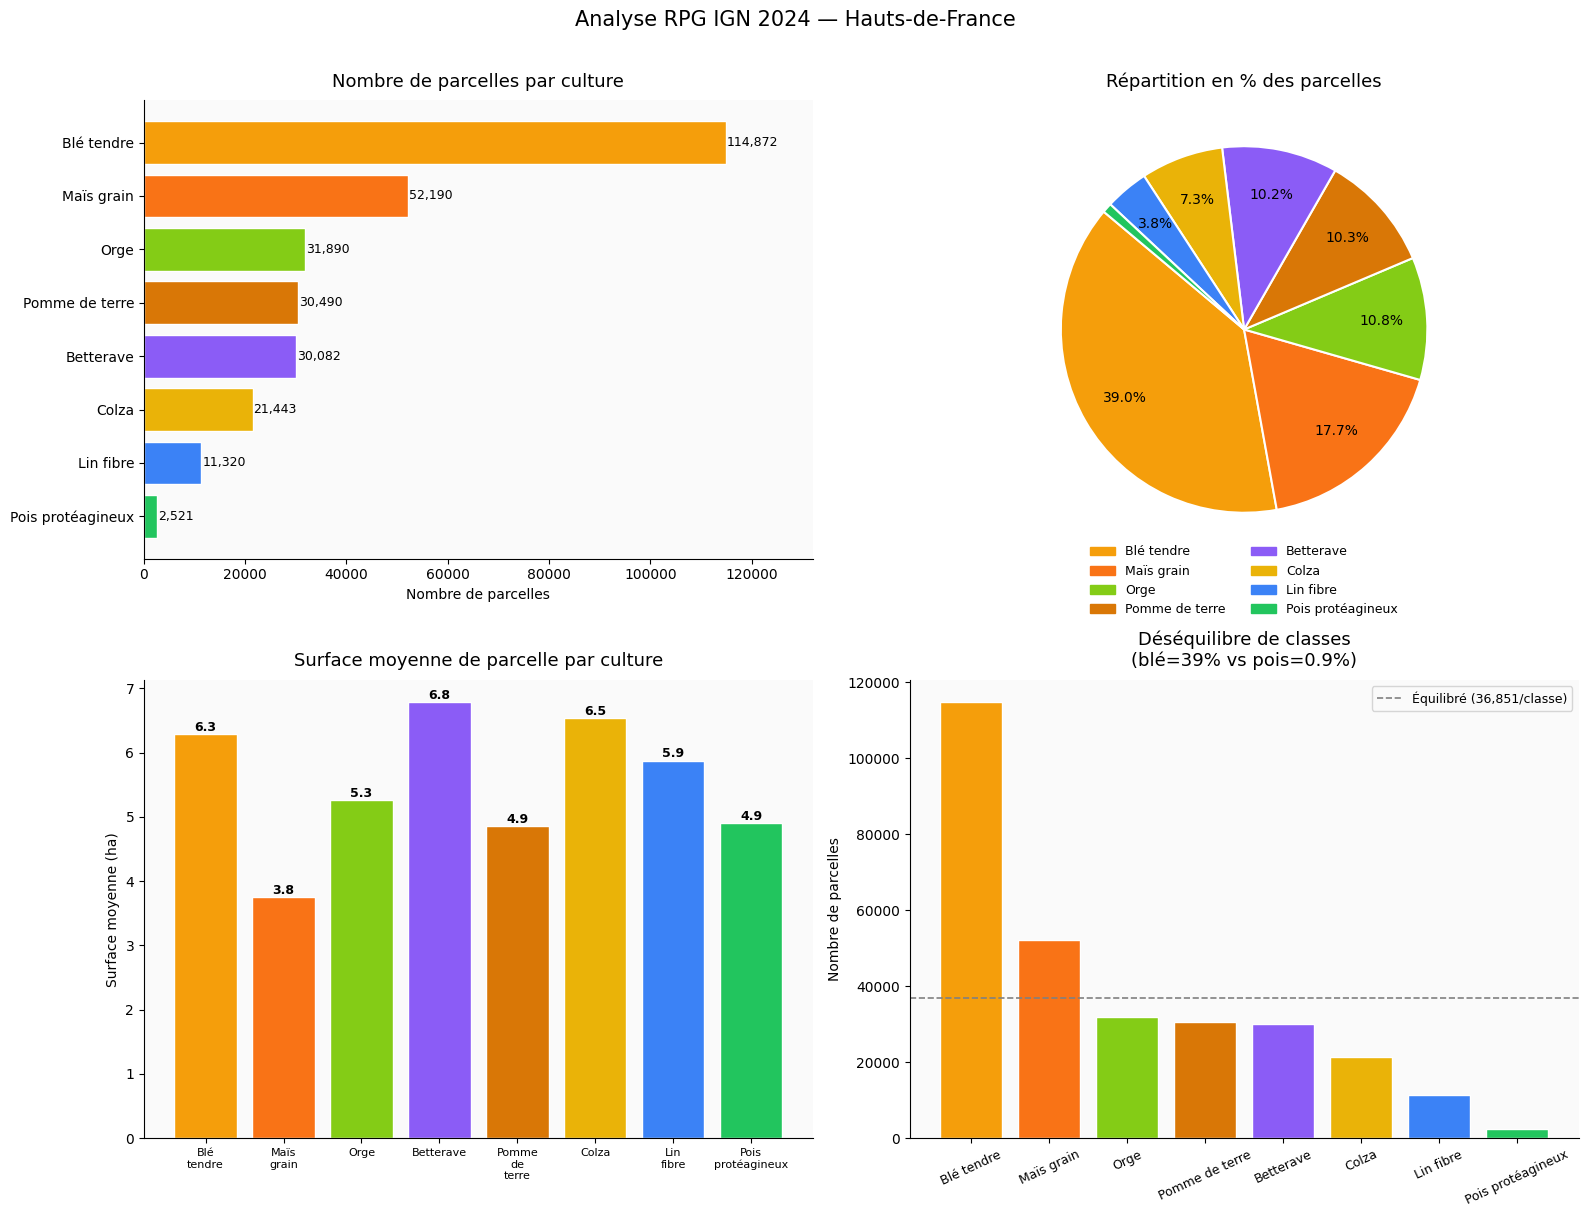

✓ rpg_analyse_complete.png sauvegardé


In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 11 — Visualisations                             ║
# ╚══════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cultures_ord = dist.index.tolist()
colors  = [COULEURS[c] for c in cultures_ord]
noms_ord = [NOMS[c] for c in cultures_ord]

# ── 1. Barres horizontales ──
ax = axes[0,0]
bars = ax.barh(noms_ord, dist.values, color=colors, edgecolor='white')
ax.set_xlabel('Nombre de parcelles')
ax.set_title('Nombre de parcelles par culture', fontsize=13, pad=10)
for bar, n in zip(bars, dist.values):
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            f'{n:,}', va='center', fontsize=9)
ax.set_xlim(0, dist.max()*1.15)
ax.invert_yaxis()

# ── 2. Camembert ──
ax = axes[0,1]
wedges, _, autotexts = ax.pie(
    dist.values, colors=colors, labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for at in autotexts: at.set_fontsize(10)
ax.set_title('Répartition en % des parcelles', fontsize=13, pad=10)
patches = [mpatches.Patch(color=COULEURS[c], label=NOMS[c]) for c in cultures_ord]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5,-0.15),
          ncol=2, fontsize=9, frameon=False)

# ── 3. Surface moyenne par culture ──
ax = axes[1,0]
moyennes = [df[df['culture']==c]['surf_parc'].mean() for c in CULTURES_MODELE]
bars = ax.bar([NOMS[c].replace(' ','\n') for c in CULTURES_MODELE],
              moyennes, color=[COULEURS[c] for c in CULTURES_MODELE], edgecolor='white')
ax.set_ylabel('Surface moyenne (ha)')
ax.set_title('Surface moyenne de parcelle par culture', fontsize=13, pad=10)
for bar, m in zip(bars, moyennes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{m:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.tick_params(axis='x', labelsize=8)

# ── 4. Déséquilibre vs distribution équilibrée ──
ax = axes[1,1]
bars = ax.bar(noms_ord, dist.values,
              color=colors, edgecolor='white')
ax.axhline(len(df)/8, color='gray', linestyle='--', linewidth=1.2,
           label=f'Équilibré ({len(df)//8:,}/classe)')
ax.set_ylabel('Nombre de parcelles')
ax.set_title('Déséquilibre de classes\n(blé=39% vs pois=0.9%)', fontsize=13, pad=10)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=25, labelsize=9)

plt.suptitle('Analyse RPG IGN 2024 — Hauts-de-France', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('rpg_analyse_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ rpg_analyse_complete.png sauvegardé')

In [12]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 12 — Synthèse et téléchargements                ║
# ╚══════════════════════════════════════════════════════════╝

print('=' * 55)
print('  SYNTHÈSE — RPG IGN 2024 Hauts-de-France')
print('=' * 55)
print(f'  Source          : geoservices.ign.fr/rpg')
print(f'  Format brut     : GeoPackage .gpkg (Lambert 93)')
print(f'  Parcelles brutes: {n_total:>10,}')
print(f'  Après filtrage  : {n_f2:>10,}')
print(f'  Surface totale  : {df["surf_parc"].sum():>10,.0f} ha')
print(f'  Surface moyenne : {df["surf_parc"].mean():>10.2f} ha')
print()
print('  Fichiers produits :')
print('    rpg_parcelles_light.csv  → dataset sans géométrie')
print('    rpg_coords.csv           → centroïdes lat/lon pour jointures')
print()
print('  Variables utilisées dans le modèle ML :')
print('    culture_optimale → variable CIBLE')
print('    surf_parc        → feature numérique')
print('    id_parcel        → clé de jointure RPG2023 + SGDBE')
print('    lat / lon        → jointure spatiale sol et météo')

files.download('rpg_parcelles_light.csv')
files.download('rpg_coords.csv')
files.download('rpg_analyse_complete.png')
print('\n✓ Téléchargements lancés')

  SYNTHÈSE — RPG IGN 2024 Hauts-de-France
  Source          : geoservices.ign.fr/rpg
  Format brut     : GeoPackage .gpkg (Lambert 93)
  Parcelles brutes:    566,044
  Après filtrage  :    294,808
  Surface totale  :  1,657,208 ha
  Surface moyenne :       5.62 ha

  Fichiers produits :
    rpg_parcelles_light.csv  → dataset sans géométrie
    rpg_coords.csv           → centroïdes lat/lon pour jointures

  Variables utilisées dans le modèle ML :
    culture_optimale → variable CIBLE
    surf_parc        → feature numérique
    id_parcel        → clé de jointure RPG2023 + SGDBE
    lat / lon        → jointure spatiale sol et météo


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Téléchargements lancés
